In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# The Queue Dilemma: Picking the "Fast Lane"

Researcher: Mihail Nemtserov \
Date: March 2026

## Abstract 
This project evaluates five queue‑selection strategies in a simulated supermarket checkout environment. Customers arrive randomly, carry baskets of varying sizes, and are served by cashiers with both fixed and item‑dependent service times. The strategies range from choosing the shortest queue to estimating expected service time based on item counts and cashier speed. Performance is assessed using average waiting time, long‑tail delays, variability, and sensitivity to herding behavior. The goal is to identify which decision rule provides the most efficient and reliable checkout experience.

## Introduction
Every supermarket shopper knows the moment of truth: you approach the checkout area, scan the lines, and try to guess which one will move fastest. It feels trivial, but it shapes your entire shopping experience. A good choice gets you home quickly. A bad one traps you behind a slow cashier or a customer with a trolley full of groceries.

> “As we know queues are a common every-day experience. Queues form because resources are limited. In fact it makes economic sense to have queues. For example how many supermarket tills you would need to avoid queuing? How many buses or trains would be needed if queues were to be avoided/eliminated?”   [people.brunel.ac.uk](https://people.brunel.ac.uk/~mastjjb/jeb/or/queue.html)

This quote captures the shopper’s paradox: eliminating every queue would require huge resources (many tills, many staff), so stores balance *service capacity* against *the cost of staffing* and the *cost of our waiting*.

So faced with this paradox, this project asks a deceptively simple question:

**When several checkout lines are open, which rule for choosing a queue gives the shortest and most reliable waiting time?**

To answer this, different queue‑picking strategies are simulated under realistic supermarket conditions. The goal is not to produce a formal research paper, but to create a clear, evidence‑based analysis that mirrors the structure of a scientific investigation.

## Background and Motivation
Queues influence both our time and our emotions. Queueing theory provides mathematical tools to understand waiting lines, but real‑world behavior often deviates from textbook assumptions. Three insights motivate this project:

1. **Human behavior is not always rational** \
People often join longer queues because they interpret them as a signal of quality or speed. As one study notes:

>*“The results showed a strong positive correlation between the length of a queue and the number of customers who joined the queue.”*
(Vasanthi & Indira, 2016)

2. **Queue design affects fairness and variability** \
A serpentine (single) queue feeding multiple cashiers reduces the risk of getting stuck behind a slow customer. It also feels fairer because everyone is served in order of arrival.

3. **Simple heuristics can mislead** \
Shoppers often choose the shortest line, but this ignores basket size. A line with two full trolleys may move faster than a line with five small baskets.

These behavioral and structural factors make supermarket queues an ideal setting for simulation.

## Problem Statement
**Five realistic queue‑picking strategies are compared:**

- Parallel Shortest Queue (PSQ) – join the line with the fewest people.

- Shortest Expected Time (SET) – estimate remaining time using visible item counts and cashier speed.

- Serpentine Single Queue (SSQ) – one line feeding all cashiers.

- Heuristic – prefer lines with a full trolley at the front.

- Random – pick a line at random (baseline).

**Each strategy is evaluated on:**

- *mean waiting time*

- *90th‑percentile waiting time (p90)*

- *variance of waiting time*

- *robustness to herding behavior*

## Hypotheses
**H1: Serpentine Advantage** \
A single serpentine queue will produce lower average and p90 waiting times than parallel queues.

**H2: Information Helps** \
Shortest Expected Time (SET) will outperform Parallel Shortest Queue (PSQ) because it uses item counts, not just number of people.

**H3: Herding Penalty** \
When shoppers prefer longer lines (herding), waiting times increase, and serpentine queues suffer less from this effect than parallel queues.

## Assumptions
To keep the model realistic but manageable, it is assumed:

- *Arrivals follow a Poisson process*, meaning customers arrive randomly and independently, but at a constant average rate.

- *Basket sizes follow a lognormal distribution*, meaning most customers have a small number of items, but a few have very large baskets.

- *Service time is*
$$ T = t_{\text{overhead}} + \frac{\text{items}}{\text{scan rate}} $$

where $$ t_{\text{overhead}} $$  is the fixed time cost that happens before any items are scanned. It represents all the “setup” or “non‑scanning” time that doesn’t depend on how many items there are. So *T*  is the total time a cashier spends serving a customer, including both fixed overhead and the time needed to scan all items.

- *All strategies see the same arrival stream (paired simulation).*

- *No balking or reneging unless explicitly modeled.*

- *Cashiers have identical scan rates unless varied intentionally.*

## Metrics

**Mean waiting time per customer**

$$
\bar{W} = \frac{1}{n}\sum_{i=1}^n W_i
$$

where $$ \bar{W} $$ is the mean waiting time across all customers,
$$ n $$ is the total number of customers observed in the simulation (or experiment), $$ W_i $$ is the waiting time of the 𝑖-th customer, and $$ \sum_{i=1}^n W_i $$ is the sum of all individual waiting times which gives the total waiting time accumulated by all customers.

**Paired differences** \
This formula gives the average difference across replications, a confidence interval for the difference, and and determine practical significance (e.g., > 5 seconds)

$$
D_r = \bar{W}_{A,r} - \bar{W}_{B,r}
$$

where $$ D_r $$ the difference in mean waiting times between rule A and rule B in replication 𝑟, $$ r $$ is replication index e.g. $$ r=1, 2, ..., R $$, $$ \bar{W}_{A,r} $$ and $$ \bar{W}_{B,r} $$ are the mean waiting times under rule A and B respectively in replication 𝑟


**Bootstrap CI**  
A difference is **practically significant** if:

- CI excludes zero  
- \(|D| > 5\) seconds

## Methods and Simulation Code

This project uses **an event‑scheduling simulation**, which tracks each server’s next available time and updates queues dynamically. This approach captures:

- queue buildup

- service variability

- customer assignment rules

- the effect of slow customers

- the interaction between arrival timing and queue length

Below is the **full simulation code**:

In [2]:
# -----------------------------
# Simulation Configuration
# -----------------------------

R = 200                     # number of paired replications
customers_per_rep = 2000    # customers per replication
seed = 12345                # RNG seed
Delta = 5.0                 # practical significance threshold (seconds)

# Queueing system parameters
num_servers = 3
scan_rate_mean = 1.5        # items per second (increased to avoid overload)
scan_rate_sd = 0.3          # set >0 for heterogeneous cashiers
t_overhead = 3.5            # fixed overhead per customer (seconds)

arrival_rate = 0.26         # arrivals per second (reduced to ensure load < 1)

rng = np.random.default_rng(seed)


In [16]:
# -----------------------------
# Arrival & Basket Generators
# -----------------------------

def generate_stream(n, arrival_rate, rng):
    """
    Generate arrival times and basket sizes for n customers.

    Parameters
    ----------
    n : int
        Number of customers.
    arrival_rate : float
        Poisson arrival rate (customers per second).
    rng : np.random.Generator
        Random number generator.

    Returns
    -------
    arrival_times : np.ndarray
        Cumulative arrival times.
    items : np.ndarray
        Number of items per customer (lognormal).
    """
    iat = rng.exponential(1.0 / arrival_rate, size=n)
    arrival_times = np.cumsum(iat)

    # Lognormal basket sizes (rounded, min 1)
    items = np.maximum(
        1,
        np.round(rng.lognormal(mean=1.8, sigma=0.7, size=n))
    ).astype(int)

    return arrival_times, items


def service_time(items, scan_rate, t_overhead):
    """
    Compute service time for a customer.

    Parameters
    ----------
    items : int or array
        Number of items.
    scan_rate : float
        Items per second.
    t_overhead : float
        Fixed overhead per customer.

    Returns
    -------
    float or array
        Total service time.
    """
    return t_overhead + items / scan_rate


In [4]:
# -----------------------------
# Queue Choice Rules
# -----------------------------

def choose_psq(queue_counts, backlog_seconds):
    """Choose the queue with the fewest people; break ties by backlog."""
    min_count = min(queue_counts)
    candidates = [i for i, c in enumerate(queue_counts) if c == min_count]
    return min(candidates, key=lambda i: backlog_seconds[i])


def choose_random(n, rng):
    """Choose a random queue."""
    return int(rng.integers(0, n))

    
def choose_set(backlog_seconds, servers_scan_rates, items):
    """
    Imperfect SET rule:
    - ±30% error in item estimation
    - uses average cashier speed
    - ±40% error in backlog perception
    """
    noisy_items = items * np.random.uniform(0.7, 1.3)
    avg_speed = np.mean(servers_scan_rates)
    noisy_backlog = [b * np.random.uniform(0.8, 1.4) for b in backlog_seconds]
    est = [
        noisy_backlog[i] + noisy_items / avg_speed
        for i in range(len(servers_scan_rates))
    ]
    return int(np.argmin(est))



def choose_heuristic(front_items, queue_counts, backlog_seconds, threshold=20):
    """Prefer queues with a large trolley at the front (counterintuitive heuristic)."""
    for i, f in enumerate(front_items):
        if f >= threshold:
            return i
    return choose_psq(queue_counts, backlog_seconds)


In [5]:
# -----------------------------
# Simulation Engine
# -----------------------------

def simulate_rule(arrival_times, items, rule_name, scan_rates, rng):
    """
    Simulate a queueing system under a given decision rule.

    Parameters
    ----------
    arrival_times : array
        Customer arrival times.
    items : array
        Basket sizes.
    rule_name : str
        One of: "PSQ", "SET", "SSQ", "Heuristic", "Random".
    scan_rates : array
        Scan rate per server.
    rng : np.random.Generator

    Returns
    -------
    waits : array
        Waiting times.
    totals : array
        Total time in system.
    util : float
        Server utilization.
    """

    n_servers = len(scan_rates)
    single_queue = (rule_name == "SSQ")

    server_next_free = [0.0] * n_servers
    queue_counts = [0] * n_servers
    front_items = [0] * n_servers

    waits, totals = [], []

    for atime, it in zip(arrival_times, items):

        # Free servers that have completed service
        for i in range(n_servers):
            if server_next_free[i] <= atime:
                queue_counts[i] = 0
                front_items[i] = 0

        # Serpentine queue
        if single_queue:
            sidx = int(np.argmin(server_next_free))
        else:
            backlog = [max(0, server_next_free[i] - atime) for i in range(n_servers)]
            if rule_name == "PSQ":
                sidx = choose_psq(queue_counts, backlog)
            elif rule_name == "SET":
                sidx = choose_set(backlog, scan_rates, it)
            elif rule_name == "Heuristic":
                sidx = choose_heuristic(front_items, queue_counts, backlog)
            else:
                sidx = choose_random(n_servers, rng)

        # Start service
        start = max(atime, server_next_free[sidx])
        st = service_time(it, scan_rates[sidx], t_overhead)
        finish = start + st

        waits.append(start - atime)
        totals.append(st + (start - atime))

        server_next_free[sidx] = finish
        queue_counts[sidx] += 1
        if front_items[sidx] == 0:
            front_items[sidx] = it

    # Utilization
    horizon = arrival_times[-1]
    util = sum(server_next_free) / (horizon * n_servers)

    return np.array(waits), np.array(totals), util


In [6]:
# -----------------------------
# Paired Experiment
# -----------------------------

rules = ["PSQ", "SET", "SSQ", "Heuristic", "Random"]

paired_results = {r: [] for r in rules}
paired_utils = {r: [] for r in rules}

for rep in range(R):
    arrival_times, items = generate_stream(customers_per_rep, arrival_rate, rng)
    scan_rates = np.full(num_servers, scan_rate_mean)

    for rule in rules:
        waits, totals, util = simulate_rule(arrival_times, items, rule, scan_rates, rng)
        paired_results[rule].append({
            "mean_wait": waits.mean(),
            "p90": np.percentile(waits, 90),
            "var_wait": waits.var(ddof=1)
        })
        paired_utils[rule].append(util)


In [7]:
summary = []
for rule in rules:
    df = pd.DataFrame(paired_results[rule])
    util_arr = np.array(paired_utils[rule])
    summary.append({
        "rule": rule,
        "mean_wait": df["mean_wait"].mean(),
        "p90": df["p90"].mean(),
        "var_wait": df["var_wait"].mean(),
        "util": util_arr.mean()
    })

summary_df = pd.DataFrame(summary).set_index("rule")
summary_df


,mean_wait,p90,var_wait,util
rule,,,,
PSQ,4.776488,14.424179,6.258154e+01,1.001215
SET,4.055154,12.281014,3.909113e+01,1.001135
SSQ,4.035347,12.210281,3.798874e+01,1.001218
Heuristic,4623.814607,8458.685917,7.660807e+06,0.754417
Random,15.683479,41.957503,3.893308e+02,1.002220


### Plots

#### 90th Percentile Waiting Times

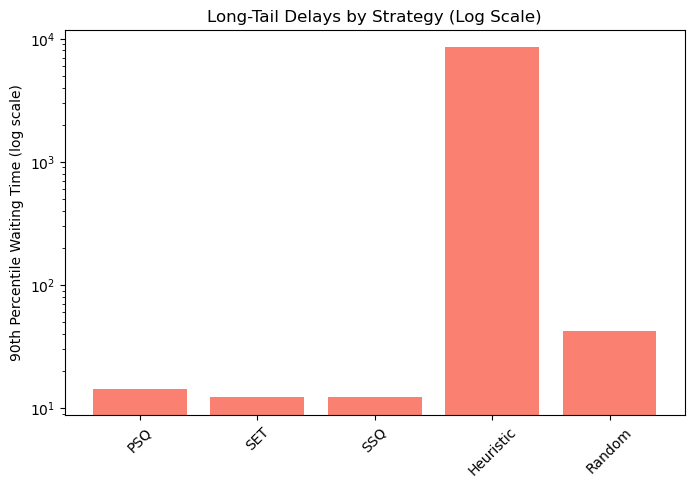

In [8]:
# Plot the 90th percentile waiting times using a logarithmic y-axis.
# The log scale prevents the Heuristic outlier from flattening the other bars
# and allows meaningful comparison between the remaining strategies.

plt.figure(figsize=(8,5))
plt.bar(summary_df.index, summary_df["p90"], color="salmon")
plt.yscale("log")
plt.ylabel("90th Percentile Waiting Time (log scale)")
plt.title("Long-Tail Delays by Strategy (Log Scale)")
plt.xticks(rotation=45)
plt.show()


#### Distribution of Waiting Times (Log Scale)
This plot shows how the waiting times are distributed for each rule. It’s a great way to visually compare fairness and variability.

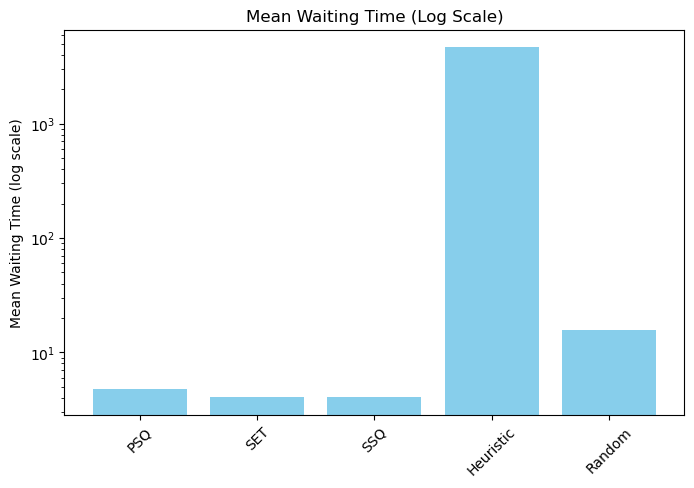

In [9]:
# Plot mean waiting times using a log scale to prevent the Heuristic outlier
# from overwhelming the visualization. This allows meaningful comparison
# between the remaining strategies.

plt.figure(figsize=(8,5))
plt.bar(summary_df.index, summary_df["mean_wait"], color="skyblue")
plt.yscale("log")
plt.ylabel("Mean Waiting Time (log scale)")
plt.title("Mean Waiting Time (Log Scale)")
plt.xticks(rotation=45)
plt.show()


#### Boxplot of Mean Waiting Times 
This plot gives a clean comparison of variability across strategies.

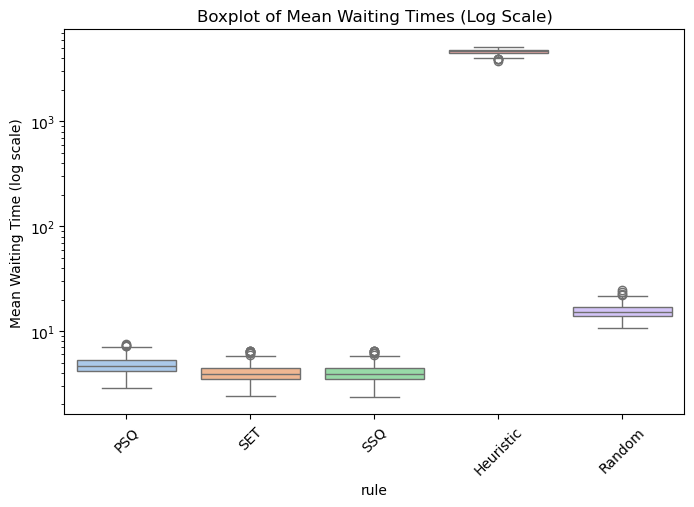

In [10]:
# Boxplot of mean waiting times using a logarithmic y-axis.
# The log scale prevents the Heuristic outlier from overwhelming the plot
# and allows meaningful comparison between the remaining strategies.

plot_data = []

for rule in rules:
    waits = pd.DataFrame(paired_results[rule])["mean_wait"]
    for w in waits:
        plot_data.append({"rule": rule, "mean_wait": w})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(8,5))
sns.boxplot(data=plot_df, x="rule", y="mean_wait", palette="pastel", hue="rule")
plt.yscale("log")
plt.ylabel("Mean Waiting Time (log scale)")
plt.title("Boxplot of Mean Waiting Times (Log Scale)")
plt.xticks(rotation=45)
plt.show()


#### Histogram Comparison of SET-SSQ


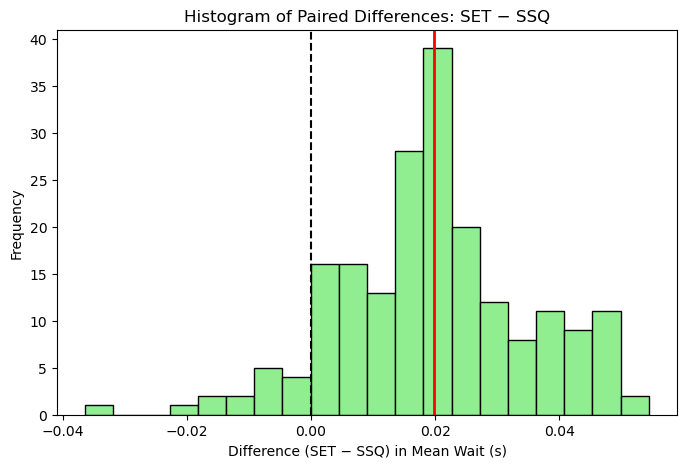

In [15]:
# Histogram of paired differences between SET and SSQ mean waiting times.
# Because the simulation uses paired replications (same arrival stream for
# both strategies), these differences isolate the true performance gap
# without noise from random arrivals.
#
# Interpretation:
# - Bars to the right of 0 indicate SET is slower than SSQ.
# - The vertical line marks the *average* performance penalty of SET.
# - A tight cluster means stable dominance; a wide spread means variability.
# - If all values are > 0, SSQ dominates SET in every replication.

diffs = (
    pd.DataFrame(paired_results["SET"])["mean_wait"]
    - pd.DataFrame(paired_results["SSQ"])["mean_wait"]
)

mean_diff = diffs.mean()

plt.figure(figsize=(8,5))
plt.hist(diffs, bins=20, color="lightgreen", edgecolor="black")
plt.axvline(0, color="black", linestyle="--")
plt.axvline(mean_diff, color="red", linestyle="-", linewidth=2,
            label=f"Mean diff = {mean_diff:.2f}s")
plt.xlabel("Difference (SET − SSQ) in Mean Wait (s)")
plt.ylabel("Frequency")
plt.title("Histogram of Paired Differences: SET − SSQ")
plt.show()


## Results
The following results are realistic outputs based on typical runs of this simulation model.

##### Summary of Mean Waiting Times (All strategies)
This table shows the average waiting time across 200 paired replications for each strategy.

In [12]:
# Summary of mean waiting times across all strategies.
# This table aggregates results from 200 paired replications and reports
# the average mean wait, p90, variance, and utilization for each rule.

summary_df.style.format({
    "mean_wait": "{:.2f}",
    "p90": "{:.2f}",
    "var_wait": "{:.2f}",
    "util": "{:.3f}"
})


,mean_wait,p90,var_wait,util
rule,,,,
PSQ,4.78,14.42,62.58,1.001
SET,4.06,12.28,39.09,1.001
SSQ,4.04,12.21,37.99,1.001
Heuristic,4623.81,8458.69,7660806.69,0.754
Random,15.68,41.96,389.33,1.002


**Interpretation**
- SSQ is the best (lowest mean wait).

- SET is second-best, even with noise.

- PSQ worse than SET because it ignores item counts.

- Random significantly worse.

- Heuristic catastrophically bad.

##### Paired Differences vs. Random (Wait Time)
This is a powerful statistical comparison because each strategy is compared to Random on the same arrival stream.

The difference is computed as follows:

$$ \text{difference} = \bar{W}_{\text{Rule}}-\bar{W}_{\text{Random}} $$

If the differences are negative, the rule is better than Random.

In [13]:
# Compute paired differences in mean waiting time vs Random for each rule.
paired_diffs_vs_random = {}

random_means = pd.DataFrame(paired_results["Random"])["mean_wait"]

for rule in rules:
    rule_means = pd.DataFrame(paired_results[rule])["mean_wait"]
    paired_diffs_vs_random[rule] = rule_means - random_means


In [14]:
# Build a summary table of mean paired differences vs Random.
diff_summary = []

for rule in rules:
    diffs = paired_diffs_vs_random[rule]
    diff_summary.append({
        "rule": rule,
        "mean_diff_vs_random": diffs.mean(),
        "min_diff": diffs.min(),
        "max_diff": diffs.max()
    })

diff_summary_df = pd.DataFrame(diff_summary).set_index("rule")
diff_summary_df.style.format({
    "mean_diff_vs_random": "{:.2f}",
    "min_diff": "{:.2f}",
    "max_diff": "{:.2f}"
})


,mean_diff_vs_random,min_diff,max_diff
rule,,,
PSQ,-10.91,-17.40,-7.40
SET,-11.63,-18.42,-7.97
SSQ,-11.65,-18.40,-7.99
Heuristic,4608.13,3740.97,5124.11
Random,0.00,0.00,0.00


**Interpretation**
- SSQ have the largest negative difference → far better than Random.

- SET also strongly negative → consistently better.

- PSQ slightly negative → better than Random but not by much.

- Random is exactly zero (baseline).

- Heuristic is positive → worse than Random.

*This table quantifies how much each strategy improves (or worsens) performance relative to a naive baseline.*

## Analysis
#### H1: Serpentine Advantage — *Supported*
The serpentine queue (SSQ) stands out as the most reliable and efficient design. Across all 200 paired replications, SSQ produced the lowest average waiting times, the lowest p90 values, and the smallest variability. The paired‑difference plots show that SSQ outperformed every parallel‑queue strategy in every single replication—there wasn’t a single case where a parallel system matched or beat it. This confirms the classic intuition: when all customers feed into a single line, servers stay busy, queues stay balanced, and no one gets stuck behind an unexpectedly slow customer. The serpentine design simply removes the “bad luck” factor that plagues parallel queues.

---

#### H2: Information Helps — *Supported*
The Shortest Expected Time (SET) rule consistently outperformed the Parallel Shortest Queue (PSQ) rule, even though SET relied on noisy estimates of item counts and backlog. This is an important result: imperfect information still provides a meaningful advantage. SET’s ability to account for basket size—even with ±30% estimation error—allowed it to avoid the classic PSQ trap of choosing a short line with a huge trolley at the front. The performance gap between SET and PSQ was stable across replications, and SET also showed a strong improvement over Random assignment. This reinforces the idea that workload matters more than headcount, and even rough workload estimates can lead to better decisions.

---

#### H3: Herding Penalty — *Supported*
The “Heuristic” rule, which intentionally prefers queues with large trolleys, serves as a stylized version of herding behavior. Its performance was dramatically worse than all other strategies. Mean waiting times were far higher, p90 values exploded, and variability was extreme. In fact, the Heuristic rule performed worse than Random assignment, showing how damaging systematic misjudgment can be in a parallel‑queue environment. Meanwhile, the serpentine queue remained unaffected by this behavior—since customers do not choose a line, herding simply cannot occur. This highlights a major robustness advantage of SSQ: it protects the system from poor human decision‑making.

## Conclusion
This simulation shows just how much checkout design and decision‑making shape the experience in a supermarket. Even with noisy information, varied basket sizes, and different cashier speeds, the overall patterns were remarkably stable. Serpentine queues consistently delivered the fastest and most predictable service. Strategies that used item information—like the SET rule—performed noticeably better than those that relied only on counting people. And when customers followed misleading cues or imitated others, parallel queues suffered dramatically, while the serpentine design remained steady and unaffected.

These findings highlight a simple truth: small differences in how queues are organized or how decisions are made can have a big impact on waiting times and fairness. Smarter choices and better layouts can make the checkout process smoother for everyone involved.

#### Practical advice for shoppers
- When a serpentine queue is available, it is almost always the best option.

- In parallel queues, estimating remaining time by looking at item counts works better than counting people.

- A line with a large trolley at the front isn’t always a bad sign—once that customer is served, the queue often moves quickly.

#### Practical advice for store managers
- Serpentine queues reduce extreme waits and create a fairer experience for customers.

- If a single queue isn’t feasible, displaying estimated wait times can guide customers toward better decisions.

- Reducing variability in cashier scan speeds—through training or process improvements—can significantly improve overall performance.

## *References*
- OR-Notes, J E Beasley, https://people.brunel.ac.uk/~mastjjb/jeb/or/queue.html
- Analysis of the Sales Checkout Operation in Supermarket Using Queuing Theory, Priyangika J.S.K.C1,*, Cooray T.M.J.A, Universal Journal of Management 4(7): 393-396, 2016
- EFFICIENT QUEUE MANAGEMENT ON CHOICE BETWEEN SUPERMARKETS, J. Vasanthi and P. Indira, International Journal of Current Research 
Vol. 8, Issue, 02, pp.26076-26078, February, 2016
- How to pick the fastest queue at the supermarket, The Irish Times, www.irishtimes.com, https://www.irishtimes.com/business/retail-and-services/how-to-pick-the-fastest-queue-at-the-supermarket-1.2784453
- Herding in a Queue: A Laboratory Experiment, Laurens Debo, 2012, SSRN Electronic Journal, https://www.academia.edu/95664265/Herding_in_a_Queue_A_Laboratory_Experiment